In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
import os 
import seaborn as sns  
import sklearn 

In [3]:
df = pd.read_csv('/Users/ashfaqohi/Programming_coding/DS/MKGHRfDS/2_100days_of_ML_Code/100-Days-Of-ML-Code/datasets/Social_Network_Ads.csv', encoding = 'latin-1')

df.head()
print(df.describe())


            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [4]:
print(df.shape)

(400, 5)


In [5]:
df.isnull().sum() #check the number of missing values

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.isnull().mean()*100 #pecentage of null values 

User ID            0.0
Gender             0.0
Age                0.0
EstimatedSalary    0.0
Purchased          0.0
dtype: float64

In [7]:
df.duplicated().sum() #nunber of duplicated values

np.int64(0)

In [8]:
df['Purchased'].value_counts() #number of purchases. 

Purchased
0    257
1    143
Name: count, dtype: int64

In [9]:
df['Purchased'].value_counts(normalize = True) * 100 #percentage who buy and who didn't 

Purchased
0    64.25
1    35.75
Name: proportion, dtype: float64

In [10]:
df.groupby("Purchased") ["EstimatedSalary"].describe()

,count,mean,std,min,25%,50%,75%,max
Purchased,,,,,,,,
0,257.0,60544.747082,24351.570102,15000.0,44000.0,61000.0,77000.0,141000.0
1,143.0,86272.727273,42064.200064,20000.0,41000.0,90000.0,122500.0,150000.0


In [11]:
df.groupby("Purchased") ["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Purchased,,,,,,,,
0,257.0,32.793774,7.985844,18.0,26.0,34.0,38.0,59.0
1,143.0,46.391608,8.612172,27.0,39.5,47.0,53.0,60.0


In [12]:
df["EstimatedSalary"].value_counts()

EstimatedSalary
72000     12
80000     11
79000     10
71000      9
75000      9
          ..
99000      1
129000     1
46000      1
64000      1
139000     1
Name: count, Length: 117, dtype: int64

In [13]:
df["EstimatedSalary"].value_counts(normalize = True) * 100

EstimatedSalary
72000     3.00
80000     2.75
79000     2.50
71000     2.25
75000     2.25
          ... 
99000     0.25
129000    0.25
46000     0.25
64000     0.25
139000    0.25
Name: proportion, Length: 117, dtype: float64

In [14]:
df.Gender.value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [15]:
print(df.sort_values(by = "Age"))

      User ID  Gender  Age  EstimatedSalary  Purchased
76   15746737    Male   18            52000          0
165  15578738  Female   18            86000          0
51   15764195  Female   18            44000          0
14   15628972    Male   18            82000          0
141  15666141  Female   18            68000          0
..        ...     ...  ...              ...        ...
393  15635893    Male   60            42000          1
370  15611430  Female   60            46000          1
223  15593715    Male   60           102000          1
355  15606472    Male   60            34000          1
371  15774744    Male   60            83000          1

[400 rows x 5 columns]


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [17]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [18]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

In [19]:
df.index

RangeIndex(start=0, stop=400, step=1)

In [20]:
df[["Age", "Purchased"]].value_counts()

Age  Purchased
35   0            29
26   0            16
41   0            15
48   1            13
37   0            13
                  ..
45   0             1
51   0             1
38   1             1
41   1             1
44   1             1
Name: count, Length: 70, dtype: int64

In [21]:
df[(df["Purchased"] ==1) & (df["Gender"] == "Male")]

,User ID,Gender,Age,EstimatedSalary,Purchased
16,15733883,Male,47,25000,1
17,15617482,Male,45,26000,1
18,15704583,Male,46,28000,1
20,15649487,Male,45,22000,1
22,15714658,Male,48,41000,1
...,...,...,...,...,...
388,15672330,Male,47,34000,1
390,15807837,Male,48,33000,1
391,15592570,Male,47,23000,1
393,15635893,Male,60,42000,1


In [22]:
df[(df["Age"] > 30) & (df["Purchased"] ==1) & (df["Gender"] == "Male")] 

,User ID,Gender,Age,EstimatedSalary,Purchased
16,15733883,Male,47,25000,1
17,15617482,Male,45,26000,1
18,15704583,Male,46,28000,1
20,15649487,Male,45,22000,1
22,15714658,Male,48,41000,1
...,...,...,...,...,...
388,15672330,Male,47,34000,1
390,15807837,Male,48,33000,1
391,15592570,Male,47,23000,1
393,15635893,Male,60,42000,1


In [23]:
df.groupby("Purchased")["Age"].mean()

Purchased
0    32.793774
1    46.391608
Name: Age, dtype: float64

In [24]:
df.groupby("Purchased")["EstimatedSalary"].mean()

Purchased
0    60544.747082
1    86272.727273
Name: EstimatedSalary, dtype: float64

In [25]:
df.groupby("Gender")["Purchased"].mean()

Gender
Female    0.377451
Male      0.336735
Name: Purchased, dtype: float64

In [26]:
df.groupby(["Gender", "Purchased"])["Age"].mean()

Gender  Purchased
Female  0            33.110236
        1            47.155844
Male    0            32.484615
        1            45.500000
Name: Age, dtype: float64

In [27]:
df.groupby(["Gender", "Purchased"])["EstimatedSalary"].mean()

Gender  Purchased
Female  0            61480.314961
        1            88714.285714
Male    0            59630.769231
        1            83424.242424
Name: EstimatedSalary, dtype: float64

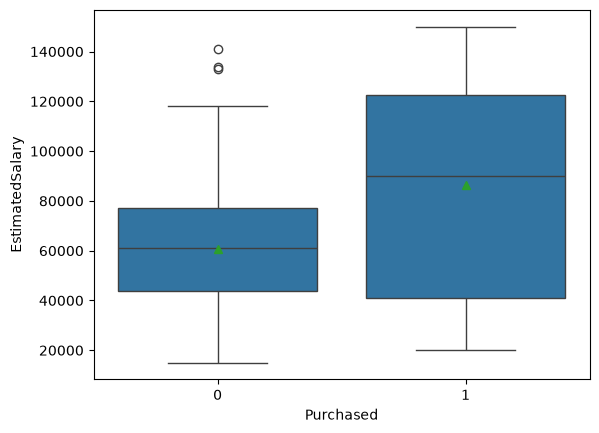

In [28]:
sns.boxplot(x="Purchased", y ="EstimatedSalary",  data = df, showmeans = True) 
plt.show()

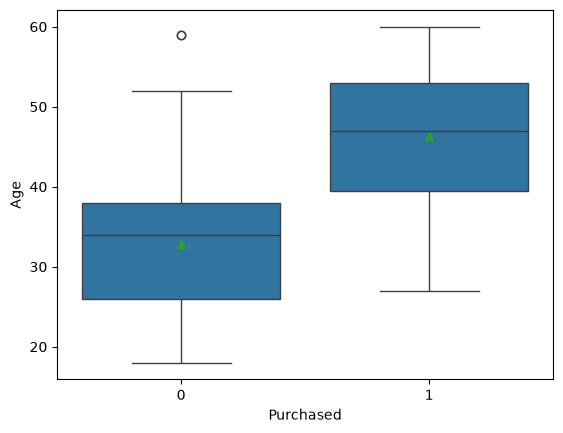

In [29]:
sns.boxplot(x="Purchased", y ="Age",  data = df, showmeans = True) 
plt.show()

In [30]:
df.groupby("Purchased")[["Age", "EstimatedSalary"]].agg(
    ["mean", "median", "min", "max"]
)

Age                EstimatedSalary                        
                mean median min max            mean   median    min     max
Purchased                                                                  
0          32.793774   34.0  18  59    60544.747082  61000.0  15000  141000
1          46.391608   47.0  27  60    86272.727273  90000.0  20000  150000

In [31]:
df["Gender"].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

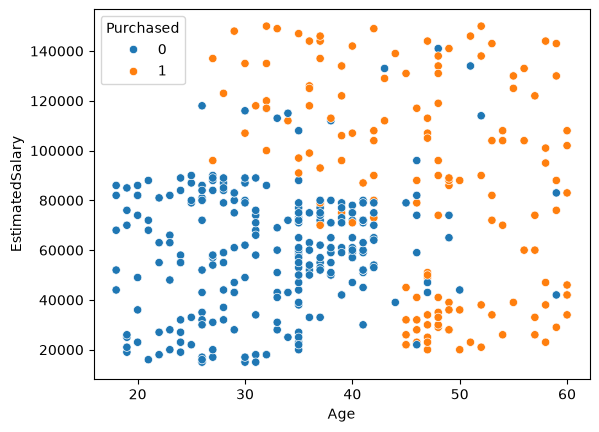

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="Age",
    y="EstimatedSalary",
    hue="Purchased"
)

plt.show()

In [33]:
df[["Age", "EstimatedSalary", "Purchased"]].corr()

,Age,EstimatedSalary,Purchased
Age,1.000000,0.155238,0.622454
EstimatedSalary,0.155238,1.000000,0.362083
Purchased,0.622454,0.362083,1.000000


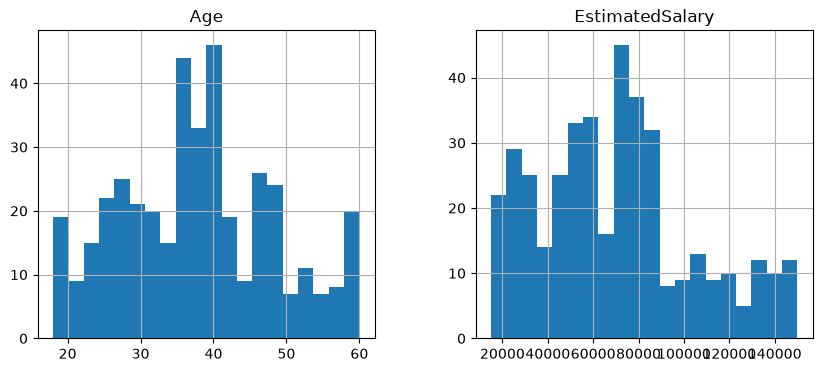

In [34]:
df[["Age", "EstimatedSalary"]].hist(
    bins=20,
    figsize=(10, 4)
)

plt.show()

In [35]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 

In [36]:
df[["Age", "EstimatedSalary", "Purchased"]].corr()

,Age,EstimatedSalary,Purchased
Age,1.000000,0.155238,0.622454
EstimatedSalary,0.155238,1.000000,0.362083
Purchased,0.622454,0.362083,1.000000


In [37]:
df["Age_cor_Purchase"]=df["Age"].corr(df["Purchased"])
df["Age_cor_Purchase"] 


0      0.622454
1      0.622454
2      0.622454
3      0.622454
4      0.622454
         ...   
395    0.622454
396    0.622454
397    0.622454
398    0.622454
399    0.622454
Name: Age_cor_Purchase, Length: 400, dtype: float64

In [38]:
X = df[["Gender", "Age", "EstimatedSalary"]] 
y =df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 2)


In [39]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,Age_cor_Purchase
0,15624510,Male,19,19000,0,0.622454
1,15810944,Male,35,20000,0,0.622454
2,15668575,Female,26,43000,0,0.622454
3,15603246,Female,27,57000,0,0.622454
4,15804002,Male,19,76000,0,0.622454


In [40]:
df.shape

(400, 6)

In [41]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased',
       'Age_cor_Purchase'],
      dtype='str')

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User ID           400 non-null    int64  
 1   Gender            400 non-null    str    
 2   Age               400 non-null    int64  
 3   EstimatedSalary   400 non-null    int64  
 4   Purchased         400 non-null    int64  
 5   Age_cor_Purchase  400 non-null    float64
dtypes: float64(1), int64(4), str(1)
memory usage: 18.9 KB


In [43]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased,Age_cor_Purchase
count,4.000000e+02,400.000000,400.000000,400.000000,4.000000e+02
mean,1.569154e+07,37.655000,69742.500000,0.357500,6.224542e-01
std,7.165832e+04,10.482877,34096.960282,0.479864,1.111613e-16
min,1.556669e+07,18.000000,15000.000000,0.000000,6.224542e-01
25%,1.562676e+07,29.750000,43000.000000,0.000000,6.224542e-01
50%,1.569434e+07,37.000000,70000.000000,0.000000,6.224542e-01
75%,1.575036e+07,46.000000,88000.000000,1.000000,6.224542e-01
max,1.581524e+07,60.000000,150000.000000,1.000000,6.224542e-01


In [44]:
X = df.drop('Purchased',axis = 1)
y=df['Purchased']

In [45]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,Age_cor_Purchase
0,15624510,Male,19,19000,0,0.622454
1,15810944,Male,35,20000,0,0.622454
2,15668575,Female,26,43000,0,0.622454
3,15603246,Female,27,57000,0,0.622454
4,15804002,Male,19,76000,0,0.622454


In [46]:
X = df.drop(['Age_cor_Purchase','Purchased','User ID'], axis=1) 
y = df['Purchased']
print(X)

     Gender  Age  EstimatedSalary
0      Male   19            19000
1      Male   35            20000
2    Female   26            43000
3    Female   27            57000
4      Male   19            76000
..      ...  ...              ...
395  Female   46            41000
396    Male   51            23000
397  Female   50            20000
398    Male   36            33000
399  Female   49            36000

[400 rows x 3 columns]


In [47]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased,Age_cor_Purchase
0,15624510,Male,19,19000,0,0.622454
1,15810944,Male,35,20000,0,0.622454
2,15668575,Female,26,43000,0,0.622454
3,15603246,Female,27,57000,0,0.622454
4,15804002,Male,19,76000,0,0.622454


In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 3)
(80, 3)
(320,)
(80,)


In [49]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 320 entries, 205 to 168
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           320 non-null    str  
 1   Age              320 non-null    int64
 2   EstimatedSalary  320 non-null    int64
dtypes: int64(2), str(1)
memory usage: 10.0 KB


In [50]:
numerical_features = ['Age', 'Salary'] 
catergorical_features = ['Gender'] 

from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
 
